# Netflix Titles Dataset – Exploratory Analysis & Insights

## Author
Ayisha Mariyam

This project explores the **Netflix Titles Dataset** to identify content trends, popular genres, and country-wise distribution of Netflix content.

---

## 🎯 Objective

Explore media content data and identify:

- Viewing trends
- Distribution of Movies vs TV Shows
- Popular genres
- Top content producing countries
- Year-wise content trends

---

## 🧠 Skills Demonstrated

- Data cleaning and preprocessing
- Working with datetime data
- Feature engineering
- Groupby and value_counts analysis
- Data visualization using Matplotlib and Seaborn
- Insight generation

---

## 📂 Dataset

Netflix Titles Dataset (~9000 records)

Features include:

- Title
- Type (Movie / TV Show)
- Director
- Cast
- Country
- Date Added
- Release Year
- Genre
- Duration

In [55]:
# Import core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Visualization style
sns.set_style("whitegrid")
sns.set_palette("mako")

print("Core libraries loaded")

Core libraries loaded


In [56]:
import sys
import os

# Get absolute path to project root (Month 2)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

print("Path added:", project_root)

Path added: e:\VS CODE\The Skybrisk Internship 3 months\Month 2


In [57]:
# Import project modules from src

from src.data_cleaning import load_data
from src.utils import dataset_overview, check_missing_values, save_clean_data

print("Project modules imported successfully")

Project modules imported successfully


#  Load Dataset

Dataset location: data/raw/netflix_titles.csv



We load the dataset using the reusable function from the **src folder**.

In [58]:
df = load_data("../data/raw/netflix_titles.csv")

df.head()

Dataset Loaded Successfully


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#  Data Understanding

We examine:

- Dataset structure
- Column types
- Statistical summary

In [59]:
dataset_overview(df)


DATASET INFO

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None

SUMMARY STATISTICS

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [60]:
print("Dataset shape:", df.shape)

Dataset shape: (8807, 12)


#  Missing Values Analysis

In [61]:
check_missing_values(df)


MISSING VALUES

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


#  Data Cleaning

Cleaning steps:

1. Convert `date_added` to datetime
2. Fill missing values in `director` and `cast`
3. Clean missing values in `country`, `date_added`, `duration`, `rating`

In [62]:
# Convert date column

df["date_added"] = pd.to_datetime(df["date_added"].astype(str).str.strip(), errors="coerce")

In [63]:
# Fill missing director values

df["director"] = df["director"].fillna("Unknown")

In [64]:
# Fill missing cast values

df["cast"] = df["cast"].fillna("Unknown")

In [65]:
# Fill missing country values

df["country"] = df["country"].fillna("Unknown")

In [66]:
# Fill missing rating values

df["rating"] = df["rating"].fillna("Not Rated")

In [67]:
# Fill missing duration values

df["duration"] = df["duration"].fillna("0 Unknown")

In [68]:
# Fill missing date added values

median_date = df["date_added"].median()

df["date_added"] = df["date_added"].fillna(median_date)

In [69]:
check_missing_values(df)


MISSING VALUES

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


#  Feature Engineering

## Create release_decade feature

In [70]:
df["release_decade"] = (df["release_year"] // 10) * 10

## Create is_movie feature

In [71]:
df["is_movie"] = df["type"].apply(lambda x: 1 if x == "Movie" else 0)

## Extract content_type

In [72]:
df["content_type"] = df["type"]

#  Country Popularity

In [73]:
top_countries = df["country"].value_counts().head(5)

top_countries

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
Name: count, dtype: int64

#  Exploratory Data Analysis

## Movies vs TV Shows Distribution

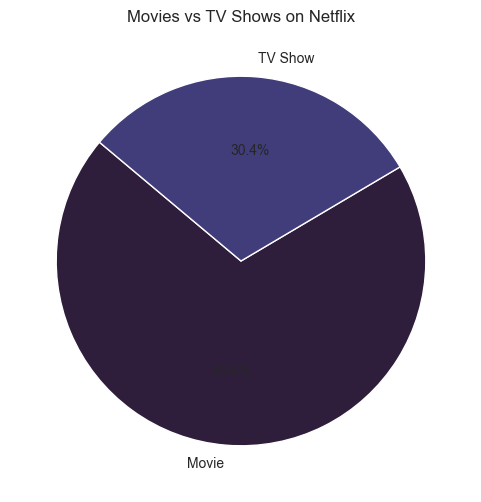

In [74]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Movies vs TV Shows on Netflix")

plt.show()

## Content Released per Year

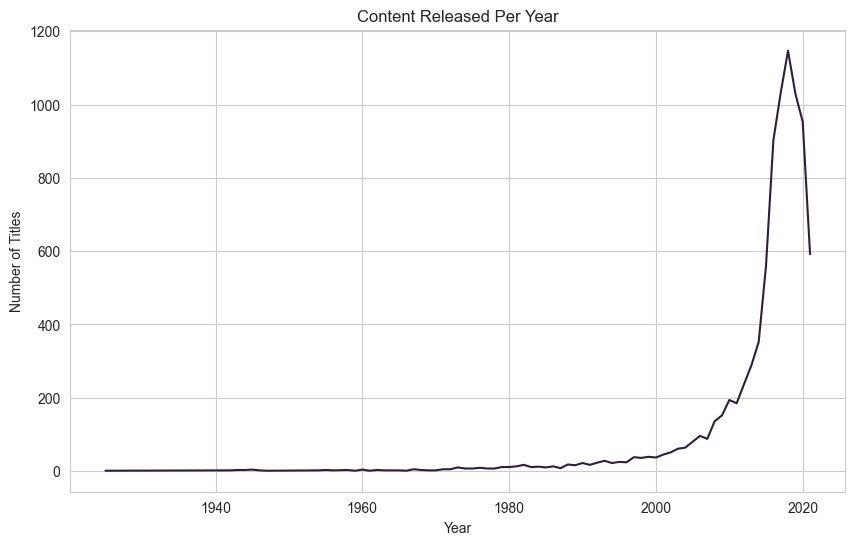

In [75]:
yearly_content = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10,6))

plt.plot(yearly_content.index, yearly_content.values)

plt.title("Content Released Per Year")

plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

## Top 10 Genres

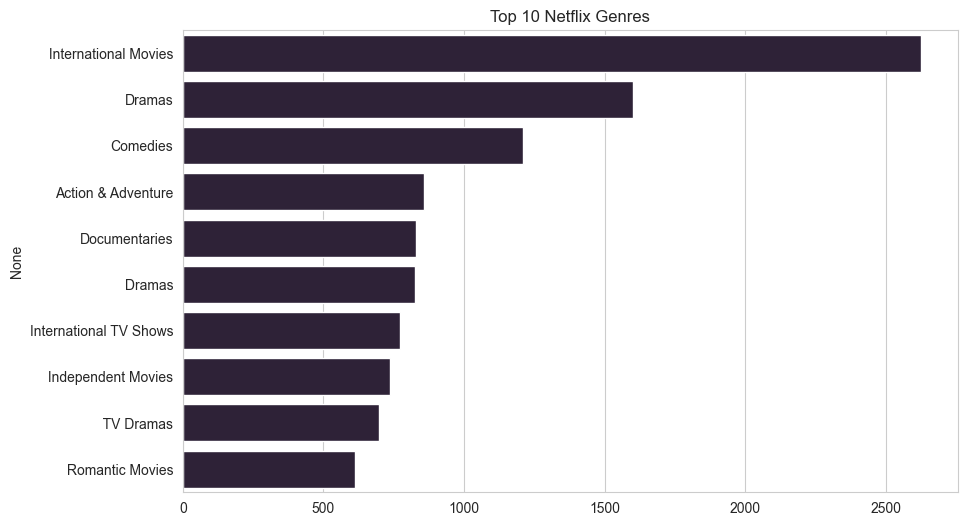

In [76]:
genres = df["listed_in"].str.split(",", expand=True).stack()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres")

plt.show()

## Top Countries Producing Netflix Content

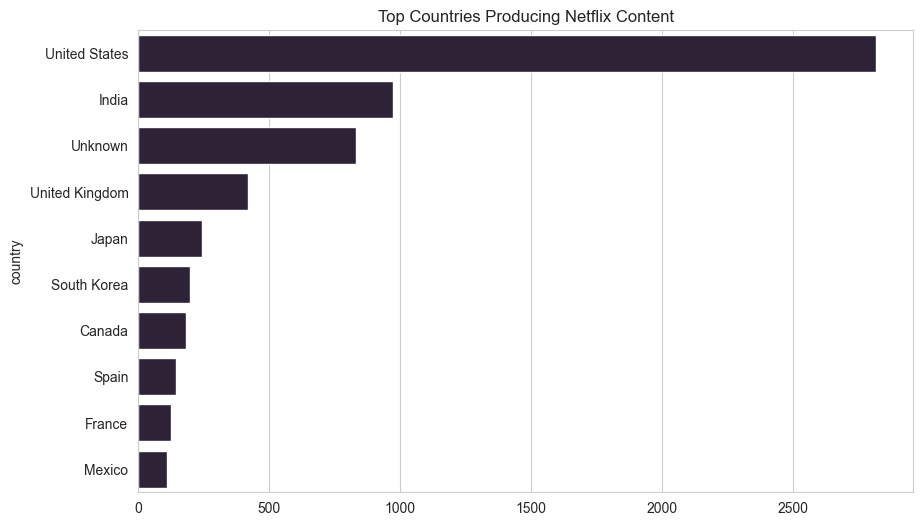

In [77]:
country_counts = df["country"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top Countries Producing Netflix Content")

plt.show()

## Country vs Content Type Heatmap

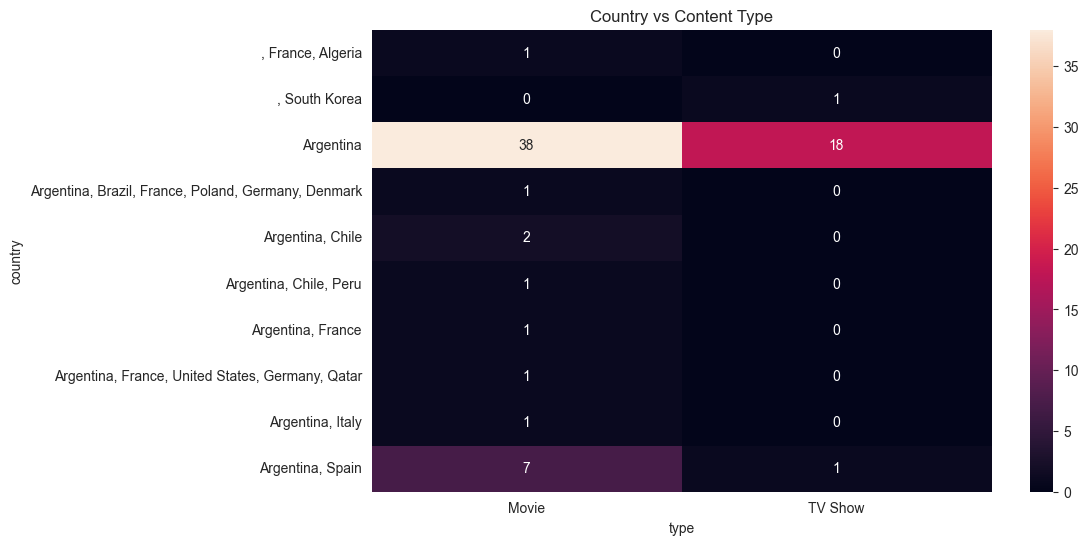

In [78]:
country_type = pd.crosstab(df["country"], df["type"]).head(10)

plt.figure(figsize=(10,6))

sns.heatmap(country_type, annot=True, fmt="d")

plt.title("Country vs Content Type")

plt.show()

#  Trend Prediction (Next 2 Years)

In [79]:
recent_years = yearly_content.tail(5)

growth_rate = recent_years.pct_change().mean()

last_value = yearly_content.iloc[-1]

prediction_1 = int(last_value * (1 + growth_rate))
prediction_2 = int(prediction_1 * (1 + growth_rate))

print("Predicted content releases next year:", prediction_1)
print("Predicted content releases in 2 years:", prediction_2)

Predicted content releases next year: 526
Predicted content releases in 2 years: 467


#  Key Insights

1. Movies dominate Netflix catalog compared to TV Shows.
2. Content production increased significantly after 2015.
3. The United States produces the largest number of Netflix titles.
4. Drama and international genres are the most common categories.
5. Netflix content production has grown steadily each year.
6. If the trend continues, the number of titles released annually will keep increasing.

# What Does This Mean?

These insights highlight Netflix’s global content expansion strategy.

Key observations:

- Netflix invests heavily in movies compared to TV shows.
- Global markets contribute significantly to Netflix's content diversity.
- Increasing yearly content production indicates the rapid growth of streaming platforms.

Understanding these patterns helps guide future content production strategies.

#  Save Cleaned Dataset

In [80]:
save_clean_data(df, "../data/processed/netflix_titles_cleaned.csv")


Cleaned dataset saved to: ../data/processed/netflix_titles_cleaned.csv


# Conclusion

In this project we explored the Netflix Titles dataset and identified key trends in content production.

### Key Achievements

✔ Cleaned dataset  
✔ Created new features  
✔ Generated multiple visualizations  
✔ Identified global content trends  
✔ Predicted future content growth  

This dataset can be further used for:

- Recommendation systems
- Content analytics dashboards
- Machine learning models